# NetVLAD thesis figures

This notebook evaluates every completed NetVLAD variant on dataset-2, selects the strongest variant by Recall@1, and exports polished thesis figures. Run `netvlad.ipynb` first to create any missing similarity CSVs.

In [64]:
from __future__ import annotations

import csv
import importlib
import sys
import tempfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageDraw

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'thesis_figures' / 'netvlad'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATABASE_DIR = PROJECT_ROOT / 'datasets' / 'dataset-2' / 'frames-IMG_3609'
QUERY_DIR = PROJECT_ROOT / 'datasets' / 'dataset-2' / 'frames-IMG_3610'
DATABASE_LABELS_CSV = PROJECT_ROOT / 'datasets' / 'dataset-2' / 'labels' / 'frames-IMG_3609.csv'
QUERY_LABELS_CSV = PROJECT_ROOT / 'datasets' / 'dataset-2' / 'labels' / 'frames-IMG_3610.csv'
SIMILARITY_FILES = sorted((PROJECT_ROOT / 'outputs' / 'netvlad').glob('_netvlad_*_similarity.csv'))
TOP_K_VALUES = [1, 5, 10, 20]
TOP_CONFUSIONS = 12

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 130,
})
print(f'Figures will be saved to: {FIGURE_DIR}')
print(f'Completed NetVLAD variants: {len(SIMILARITY_FILES)}')
for path in SIMILARITY_FILES:
    print(' •', path.name)

Figures will be saved to: /Users/armin/Documents/indoor-VPR/outputs/thesis_figures/netvlad
Completed NetVLAD variants: 8
 • _netvlad_resnet101conv4_msls_similarity.csv
 • _netvlad_resnet101conv4_pitts30k_similarity.csv
 • _netvlad_resnet18conv4_msls_similarity.csv
 • _netvlad_resnet18conv4_pitts30k_similarity.csv
 • _netvlad_resnet50conv4_msls_similarity.csv
 • _netvlad_resnet50conv4_pitts30k_similarity.csv
 • _netvlad_vgg16_msls_similarity.csv
 • _netvlad_vgg16_pitts30k_similarity.csv


## Evaluate completed NetVLAD variants

In [65]:
def load_labels(path):
    with path.open(newline='', encoding='utf-8') as handle:
        return {Path(row['image_path']).name: row['label'].strip().casefold() for row in csv.DictReader(handle)}

def pretty_name(path):
    return path.stem.removeprefix('_netvlad_').removesuffix('_similarity').replace('conv', '-conv').replace('_', ' ')

database_paths = sorted(DATABASE_DIR.glob('*.jpg'))
query_paths = sorted(QUERY_DIR.glob('*.jpg'))
query_path_by_name = {path.name: path for path in query_paths}
database_label_by_name = load_labels(DATABASE_LABELS_CSV)
query_label_by_name = load_labels(QUERY_LABELS_CSV)
database_labels = np.asarray([database_label_by_name[path.name] for path in database_paths], dtype=object)
query_labels = np.asarray([query_label_by_name[path.name] for path in query_paths], dtype=object)

def top_indices(scores, k):
    k = min(k, scores.size)
    candidates = np.argpartition(scores, -k)[-k:]
    return candidates[np.argsort(-scores[candidates])]

def evaluate_file(path):
    totals = {k: 0 for k in TOP_K_VALUES}
    count_by_label, correct_by_label, confusions = Counter(), Counter(), Counter()
    examples, evaluated = [], 0
    with path.open(newline='', encoding='utf-8') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        if len(header) - 2 != len(database_paths):
            raise ValueError(f'{path.name} does not match the current database ordering.')
        for row in reader:
            query_index = int(row[0])
            query_path = query_path_by_name.get(Path(row[1]).name)
            if query_path is None:
                raise FileNotFoundError(f"Query image from CSV is missing: {row[1]}")
            true_label = query_label_by_name.get(query_path.name)
            if true_label is None:
                continue
            scores = np.asarray(row[2:], dtype=np.float32)
            ranks = top_indices(np.nan_to_num(scores, nan=-np.inf), max(TOP_K_VALUES))
            predicted_index = int(ranks[0])
            predicted_label = str(database_labels[predicted_index])
            is_correct = predicted_label == true_label
            evaluated += 1
            count_by_label[true_label] += 1
            correct_by_label[true_label] += is_correct
            confusions[(true_label, predicted_label)] += 1
            for k in TOP_K_VALUES:
                totals[k] += bool(np.any(database_labels[ranks[:k]] == true_label))
            top5_indices = ranks[:5]
            examples.append({
                'query_index': query_index, 'query_path': query_path, 'query_label': true_label,
                'database_index': predicted_index, 'database_path': database_paths[predicted_index],
                'database_label': predicted_label, 'correct': is_correct, 'score': float(scores[predicted_index]),
                'top5_indices': top5_indices, 'top5_scores': scores[top5_indices],
                'top5_correct': database_labels[top5_indices] == true_label,
            })
    return {
        'recall': {k: totals[k] / evaluated for k in TOP_K_VALUES}, 'count_by_label': count_by_label,
        'correct_by_label': correct_by_label, 'confusions': confusions, 'examples': examples, 'evaluated': evaluated,
    }

if not SIMILARITY_FILES:
    raise FileNotFoundError('No NetVLAD CSVs found. Run notebooks/netvlad.ipynb first.')
evaluations = {path: evaluate_file(path) for path in SIMILARITY_FILES}
best_path = max(SIMILARITY_FILES, key=lambda path: evaluations[path]['recall'][1])
best = evaluations[best_path]
print(f"Best completed variant: {pretty_name(best_path)} — Recall@1 {best['recall'][1]:.1%}")

Best completed variant: resnet101-conv4 pitts30k — Recall@1 78.5%


## 1. Recall at different retrieval depths — every variant

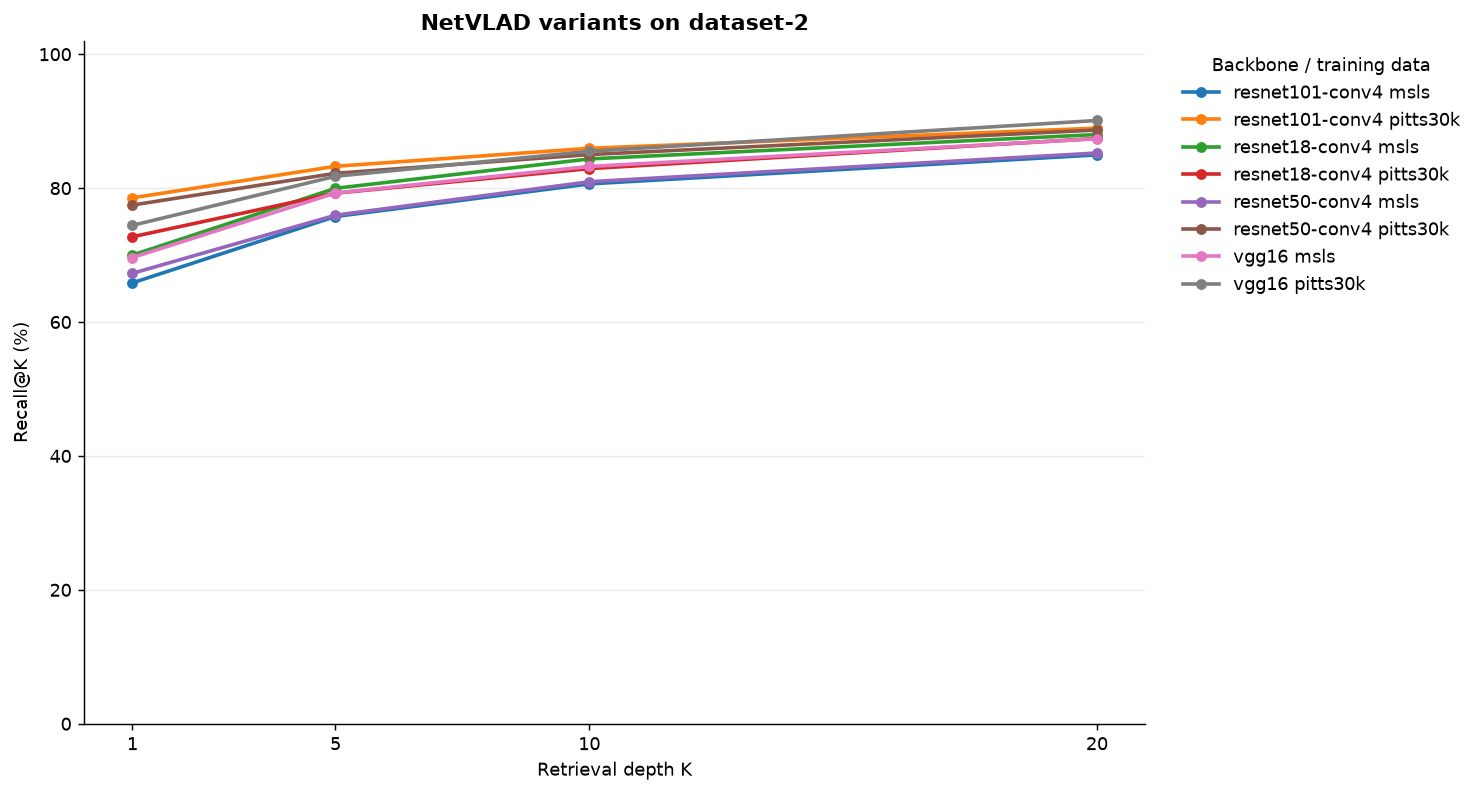

In [66]:
figure, axis = plt.subplots(figsize=(11.5, 6.2))
colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(SIMILARITY_FILES))))
for color, path in zip(colors, SIMILARITY_FILES):
    recalls = [100 * evaluations[path]['recall'][k] for k in TOP_K_VALUES]
    axis.plot(TOP_K_VALUES, recalls, marker='o', linewidth=2, markersize=5, label=pretty_name(path), color=color)
axis.set(xlabel='Retrieval depth K', ylabel='Recall@K (%)', ylim=(0, 102), xticks=TOP_K_VALUES,
         title='NetVLAD variants on dataset-2')
axis.grid(axis='y', alpha=.25)
axis.legend(title='Backbone / training data', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
figure.tight_layout()
figure.savefig(FIGURE_DIR / 'netvlad_recall_by_variant.pdf', bbox_inches='tight')
figure.savefig(FIGURE_DIR / 'netvlad_recall_by_variant.png', bbox_inches='tight', dpi=300)
plt.show()

## 2. Label-wise Recall@1 of the best variant

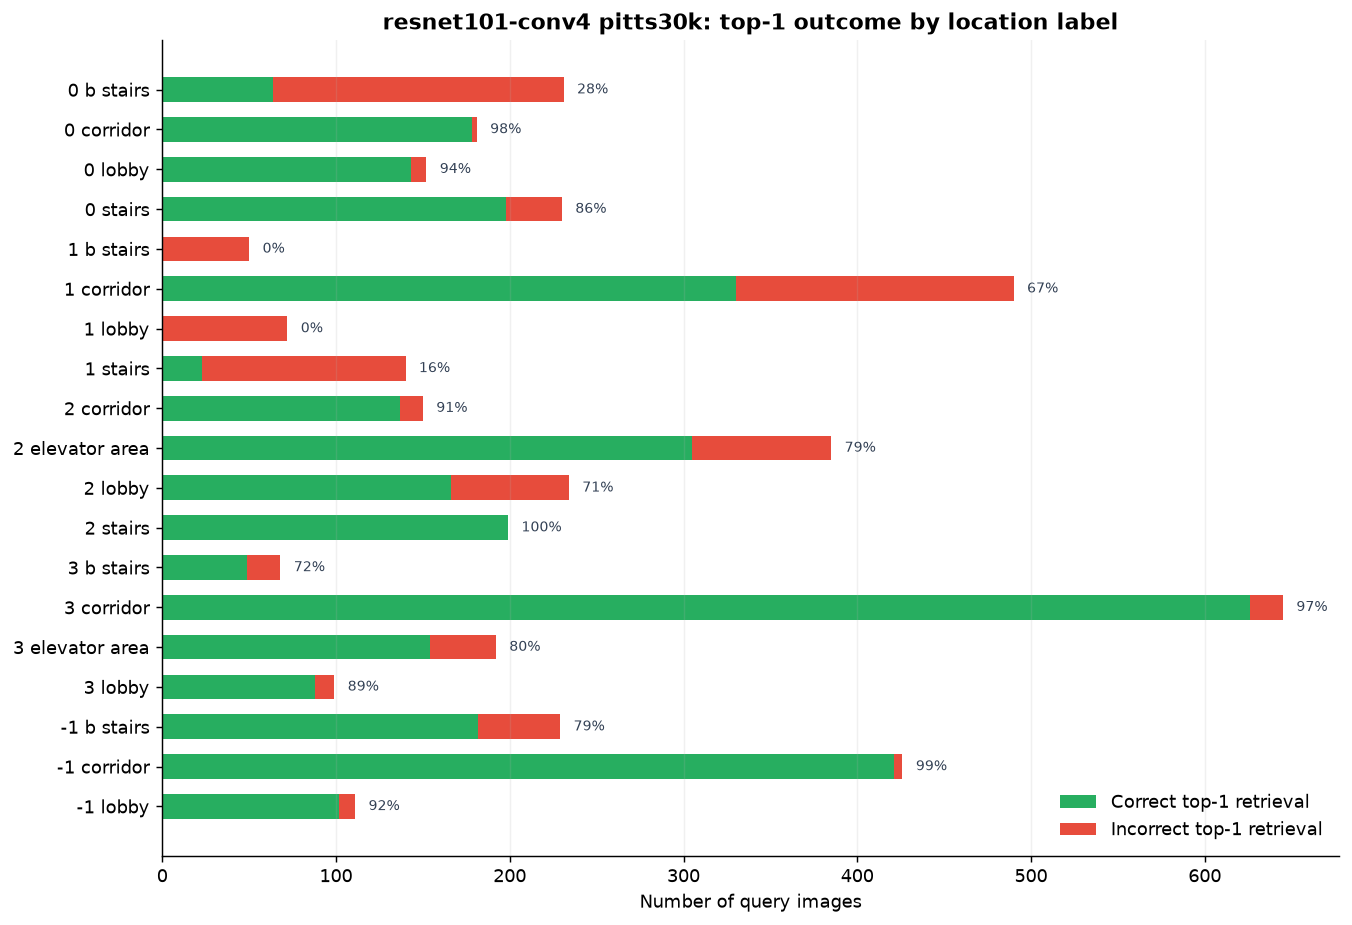

In [67]:
labels = sorted(best['count_by_label'], key=lambda label: (label.split()[0].replace('-', 'z'), label))
correct = np.array([best['correct_by_label'][label] for label in labels])
total = np.array([best['count_by_label'][label] for label in labels])
incorrect = total - correct
figure, axis = plt.subplots(figsize=(10.5, max(5.5, .38 * len(labels))))
y = np.arange(len(labels))
axis.barh(y, correct, color='#27ae60', height=.62, label='Correct top-1 retrieval')
axis.barh(y, incorrect, left=correct, color='#e74c3c', height=.62, label='Incorrect top-1 retrieval')
for yi, hit, n in zip(y, correct, total):
    axis.text(n + max(total) * .012, yi, f'{hit/n:.0%}', va='center', fontsize=8, color='#334155')
axis.set(yticks=y, yticklabels=labels, xlabel='Number of query images',
         title=f"{pretty_name(best_path)}: top-1 outcome by location label")
axis.invert_yaxis(); axis.grid(axis='x', alpha=.18); axis.legend(loc='lower right', frameon=False)
figure.tight_layout()
figure.savefig(FIGURE_DIR / 'netvlad_best_label_recall_at_1.pdf', bbox_inches='tight')
figure.savefig(FIGURE_DIR / 'netvlad_best_label_recall_at_1.png', bbox_inches='tight', dpi=300)
plt.show()

## 3. Top-1 label confusion matrix

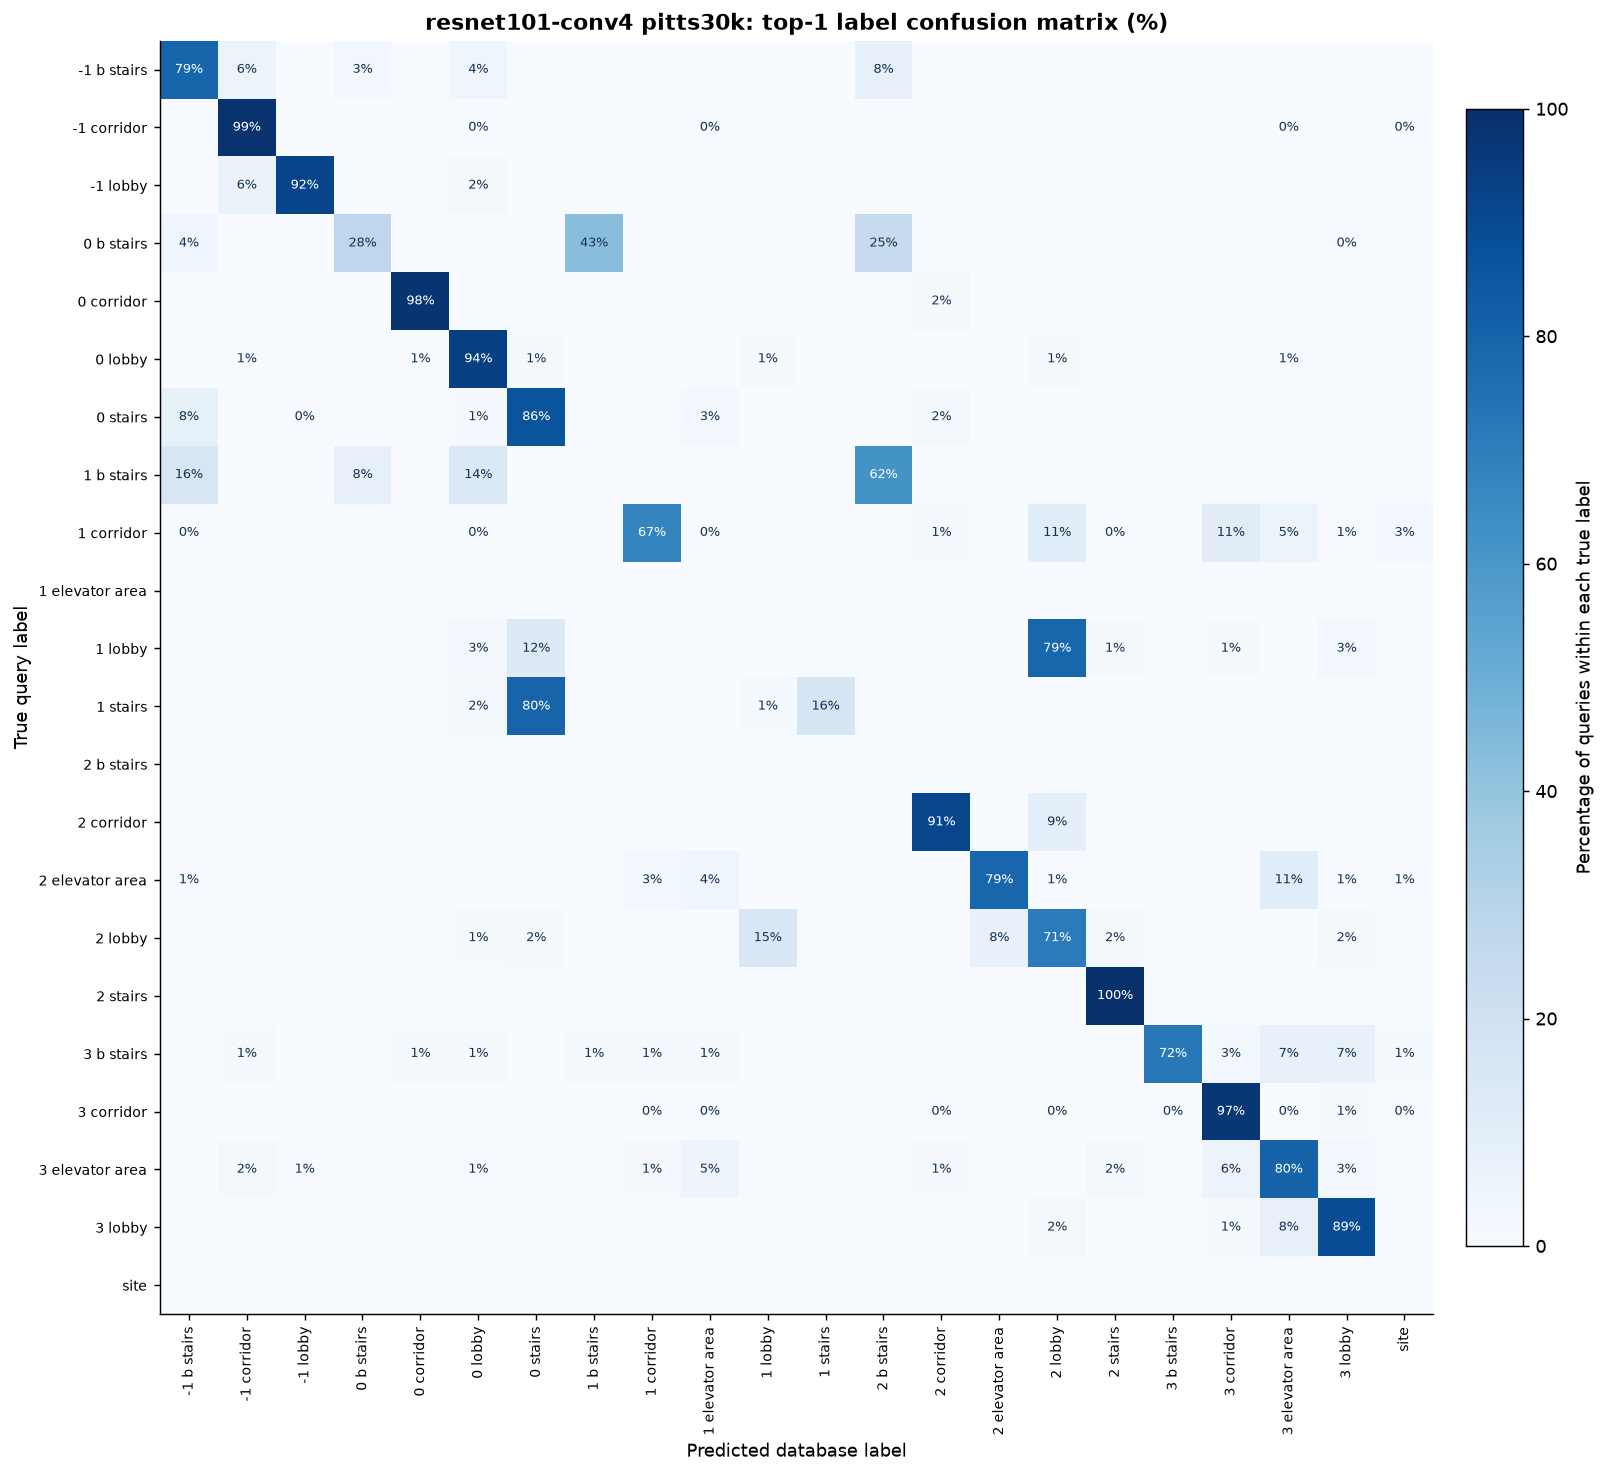

In [68]:
matrix_labels = sorted(set(best['count_by_label']) | {predicted for _, predicted in best['confusions']})
label_index = {label: index for index, label in enumerate(matrix_labels)}
matrix = np.zeros((len(matrix_labels), len(matrix_labels)), dtype=float)
for (true_label, predicted_label), count in best['confusions'].items():
    matrix[label_index[true_label], label_index[predicted_label]] += count
row_totals = matrix.sum(axis=1, keepdims=True)
percent = np.divide(matrix, row_totals, out=np.zeros_like(matrix), where=row_totals > 0) * 100

figure_size = max(10, .52 * len(matrix_labels))
figure, axis = plt.subplots(figsize=(figure_size + 2, figure_size))
image = axis.imshow(percent, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for row in range(len(matrix_labels)):
    for column in range(len(matrix_labels)):
        value = percent[row, column]
        if value > 0:
            axis.text(column, row, f'{value:.0f}%', ha='center', va='center', fontsize=7,
                      color='white' if value >= 55 else '#16324f')
axis.set(xticks=np.arange(len(matrix_labels)), xticklabels=matrix_labels,
         yticks=np.arange(len(matrix_labels)), yticklabels=matrix_labels,
         xlabel='Predicted database label', ylabel='True query label',
         title=f"{pretty_name(best_path)}: top-1 label confusion matrix (%)")
axis.tick_params(axis='x', labelrotation=90, labelsize=8); axis.tick_params(axis='y', labelsize=8)
colorbar = figure.colorbar(image, ax=axis, fraction=.035, pad=.02)
colorbar.set_label('Percentage of queries within each true label')
figure.tight_layout()
figure.savefig(FIGURE_DIR / 'netvlad_best_top1_confusion_matrix.pdf', bbox_inches='tight')
figure.savefig(FIGURE_DIR / 'netvlad_best_top1_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. Top-5 retrieval examples

The panel follows the visual style of `show_matches`: each row contains one query and its five ranked database images. It selects two rows with five correct matches and one row with exactly one incorrect match. Set `RETRIEVAL_EXAMPLE_INDICES` to three query indices to curate it manually.

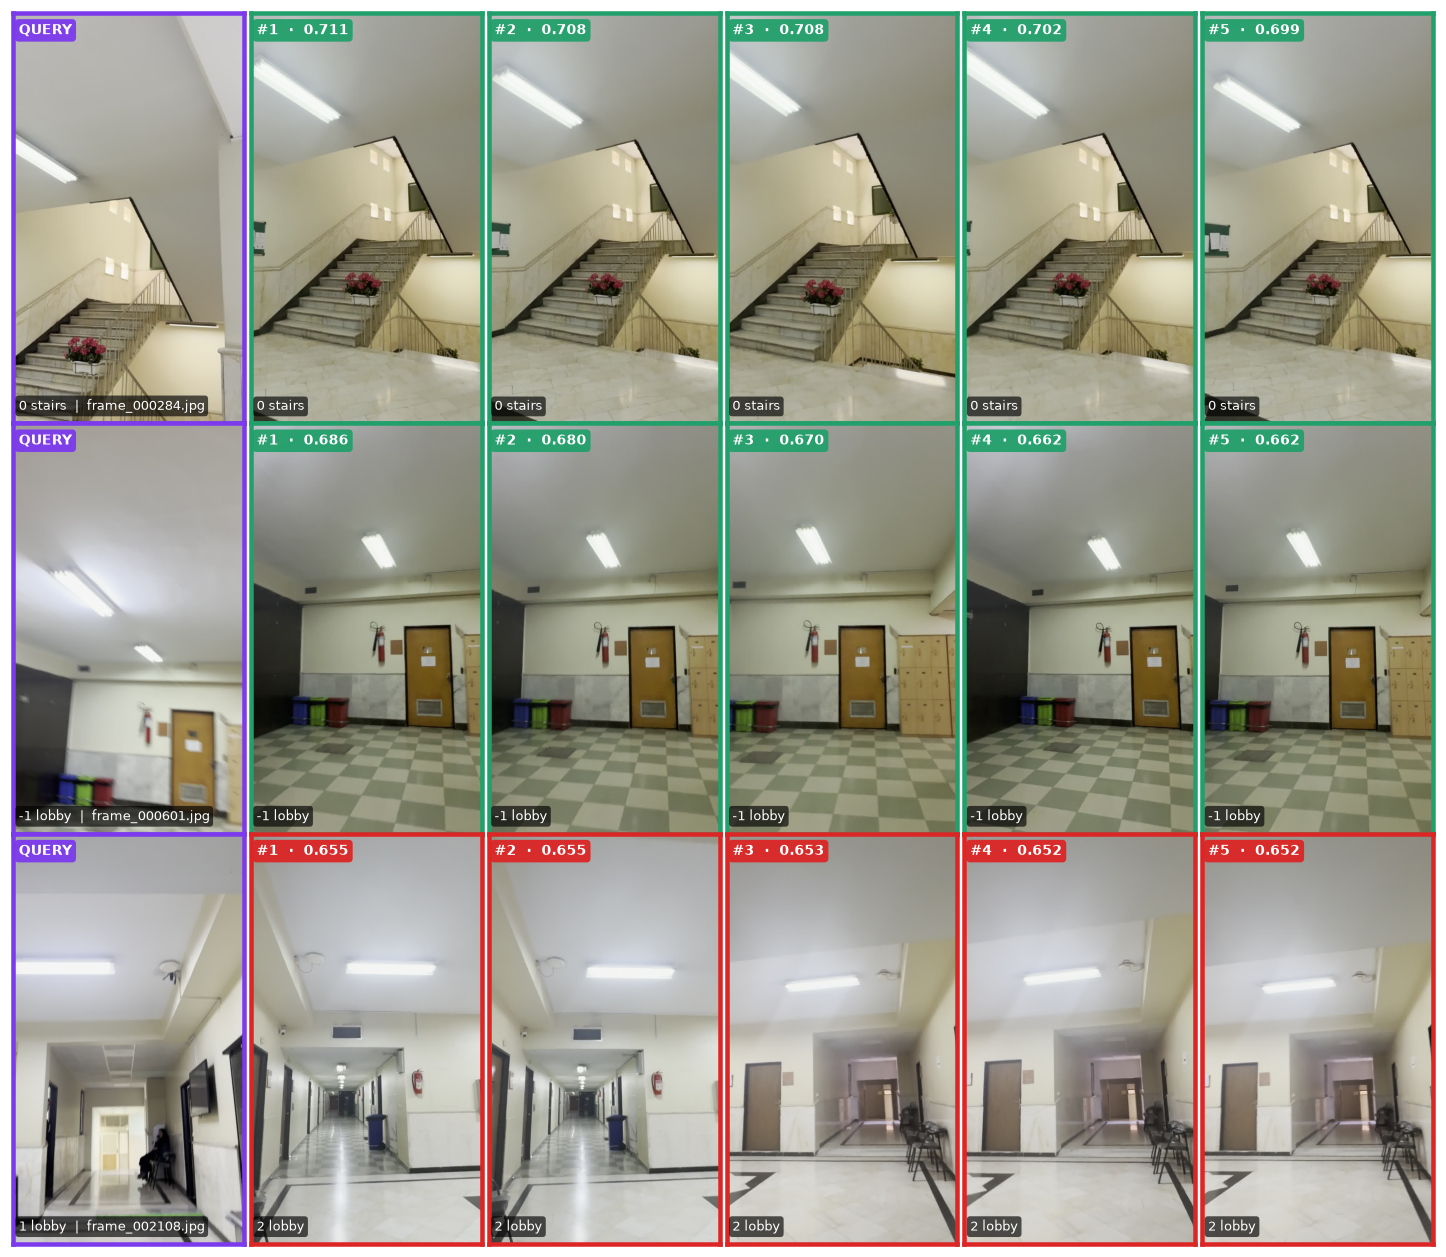

: 

In [ ]:
all_correct = [row for row in best['examples'] if len(row['top5_correct']) == 5 and row['top5_correct'].all()]
one_incorrect = [row for row in best['examples'] if len(row['top5_correct']) == 5 and row['top5_correct'].sum() == 4]
if len(all_correct) < 2 or not one_incorrect:
    raise RuntimeError('Could not find two all-correct rows and one row with exactly one top-5 error.')
retrieval_examples = [all_correct[0], all_correct[len(all_correct)//2], one_incorrect[0]]
RETRIEVAL_EXAMPLE_INDICES = [283, 600, 2107]  # Example: [12, 319, 842]
if RETRIEVAL_EXAMPLE_INDICES is not None:
    by_index = {row['query_index']: row for row in best['examples']}
    retrieval_examples = [by_index[index] if index != correct_examples[0] else index for index in RETRIEVAL_EXAMPLE_INDICES]
if len(retrieval_examples) != 3:
    raise ValueError('Choose exactly three query indices.')
# if sum(row['top5_correct'].all() for row in retrieval_examples) != 2 or sum(row['top5_correct'].sum() == 4 for row in retrieval_examples) != 1:
#     raise ValueError('Select two queries with five correct matches and one query with exactly one incorrect match.')

BACKGROUND, QUERY_COLOR, GOOD, BAD = '#ffffff', '#7C3AED', '#22a06b', '#dc2626'
def image_card(axis, image_path, header, footer, color):
    with Image.open(image_path) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(True); spine.set_linewidth(2.5); spine.set_edgecolor(color)
    axis.text(.025, .975, header, transform=axis.transAxes, ha='left', va='top', color='white', fontsize=8, fontweight='bold',
              bbox={'boxstyle': 'round,pad=.28', 'facecolor': color, 'edgecolor': 'none', 'alpha': .95})
    axis.text(.025, .025, footer, transform=axis.transAxes, ha='left', va='bottom', color='white', fontsize=7.3,
              bbox={'boxstyle': 'round,pad=.25', 'facecolor': '#000000', 'edgecolor': 'none', 'alpha': .65})

# Dataset frames are portrait, so this compact canvas lets adjacent cards touch without distortion.
figure, axes = plt.subplots(3, 6, figsize=(11, 10), facecolor=BACKGROUND, gridspec_kw={'hspace': 0, 'wspace': 0})
for row_index, row in enumerate(retrieval_examples):
    image_card(axes[row_index, 0], row['query_path'], 'QUERY', f"{row['query_label']}  |  {row['query_path'].name}", QUERY_COLOR)
    for rank, (database_index, score, is_correct) in enumerate(zip(row['top5_indices'], row['top5_scores'], row['top5_correct']), start=1):
        path = database_paths[int(database_index)]
        label = database_label_by_name[path.name]
        color = GOOD if is_correct else BAD
        image_card(axes[row_index, rank], path, f'#{rank}  ·  {score:.3f}', label, color)
# figure.suptitle(f"{pretty_name(best_path)}: correct and incorrect top-5 retrievals", y=.99, color='#172033', fontsize=15, fontweight='bold')
figure.subplots_adjust(left=.001, right=.999, bottom=.008, top=.955, hspace=.0, wspace=1)
figure.savefig(FIGURE_DIR / 'netvlad_best_top5_retrieval_examples.pdf', bbox_inches='tight', facecolor=BACKGROUND)
figure.savefig(FIGURE_DIR / 'netvlad_best_top5_retrieval_examples.png', bbox_inches='tight', dpi=300, facecolor=BACKGROUND)
plt.show()

## 5. What has NetVLAD learned? — occlusion sensitivity

This recreates the referenced NetVLAD figure: the top row is the exact image sent to NetVLAD, and the lower row is a standalone, same-aspect-ratio occlusion-sensitivity heatmap. Dark blue means little descriptor change; dark red means strong change. This cell may download the selected checkpoint the first time.

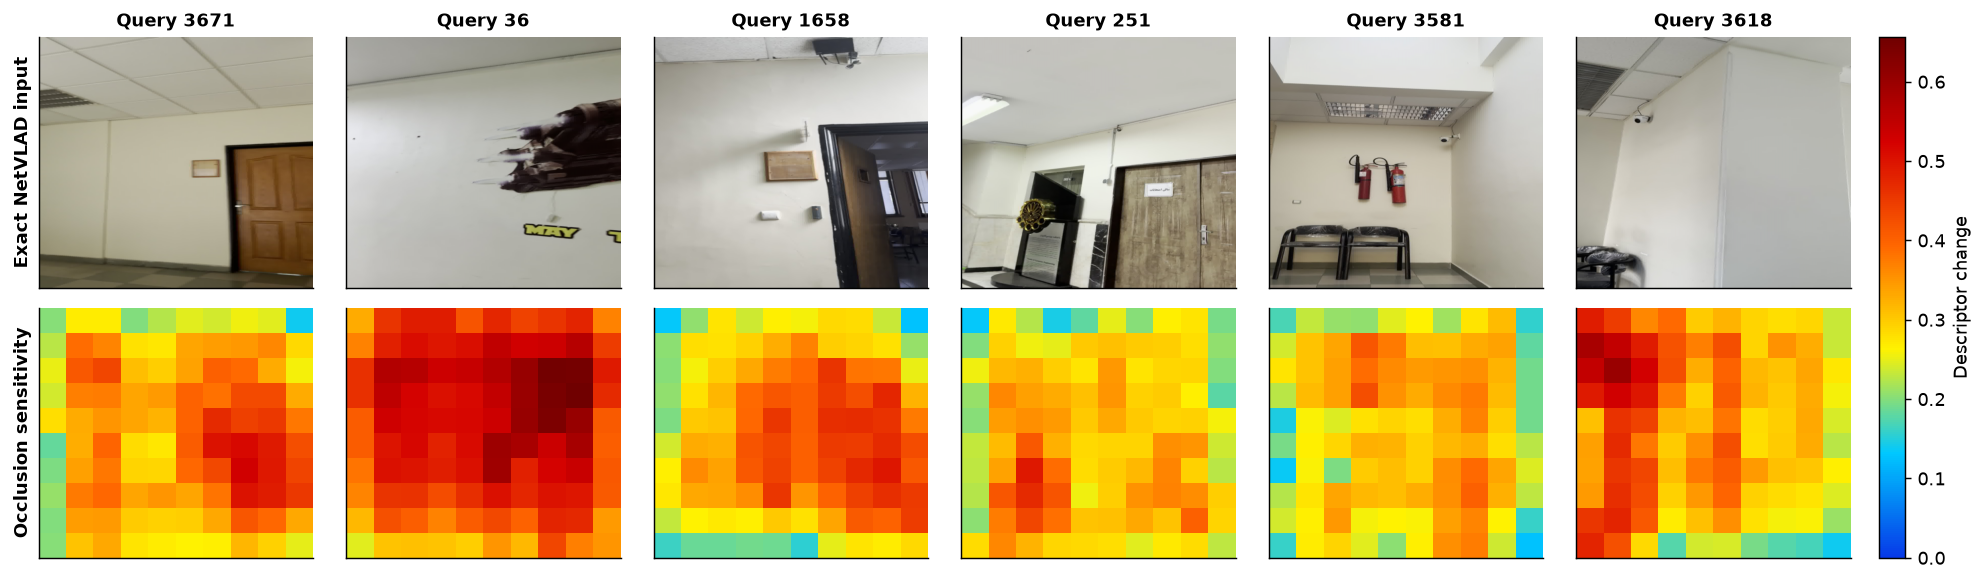

In [ ]:
import indoor_vpr.algorithms.netvlad as netvlad_module
importlib.reload(netvlad_module)
from indoor_vpr import create_algorithm

# Set explicit query indices here to curate the four columns in the final figure.
# OCCLUSION_QUERY_INDICES = [row['query_index'] for row in retrieval_examples[:4]]
OCCLUSION_QUERY_INDICES = [3671, 36, 1658, 251, 3581, 3618]
OCCLUSION_GRID = 10
OCCLUDER_FRACTION = .22

def netvlad_options(path):
    key = path.stem.removeprefix('_netvlad_').removesuffix('_similarity')
    backbone, trained_on = key.rsplit('_', 1)
    image_size = (384, 384) if backbone == 'cct384' else (480, 640)
    return {'backbone': backbone, 'trained_on': trained_on, 'image_size': image_size, 'batch_size': 8}

algorithm = create_algorithm('netvlad', **netvlad_options(best_path))

def model_input_image(image_path):
    # This is the exact resized image tensor that NetVLAD receives.
    with Image.open(image_path) as source:
        tensor = algorithm.transform(source.convert('RGB'))
    mean = algorithm.torch.tensor([.485, .456, .406])[:, None, None]
    std = algorithm.torch.tensor([.229, .224, .225])[:, None, None]
    rgb = (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    return tensor.to(algorithm.device), rgb

def encode_tensor(tensor):
    with algorithm.torch.inference_mode():
        return algorithm.model(tensor.unsqueeze(0)).squeeze(0).cpu().numpy()

def occlusion_map(image_path):
    tensor, model_rgb = model_input_image(image_path)
    height, width = tensor.shape[-2:]
    patch = max(16, round(min(width, height) * OCCLUDER_FRACTION))
    baseline = encode_tensor(tensor)
    gray = algorithm.torch.tensor([(0.5 - .485) / .229, (0.5 - .456) / .224, (0.5 - .406) / .225], device=algorithm.device)[:, None, None]
    heatmap = np.zeros((OCCLUSION_GRID, OCCLUSION_GRID), dtype=float)
    for row in range(OCCLUSION_GRID):
        for column in range(OCCLUSION_GRID):
            x = round(column * (width - patch) / max(1, OCCLUSION_GRID - 1))
            y = round(row * (height - patch) / max(1, OCCLUSION_GRID - 1))
            occluded = tensor.clone()
            occluded[:, y:y + patch, x:x + patch] = gray
            heatmap[row, column] = np.linalg.norm(baseline - encode_tensor(occluded))
    return model_rgb, heatmap

results = [occlusion_map(query_paths[index]) for index in OCCLUSION_QUERY_INDICES]
MODEL_INPUT_DIR = FIGURE_DIR / 'occlusion_model_inputs'
MODEL_INPUT_DIR.mkdir(exist_ok=True)
for query_index, (model_rgb, _) in zip(OCCLUSION_QUERY_INDICES, results):
    Image.fromarray((model_rgb * 255).round().astype(np.uint8)).save(MODEL_INPUT_DIR / f'query_{query_index:04d}_netvlad_input.png')
maximum = max(heatmap.max() for _, heatmap in results)
# Saturated low-to-high palette: blue → cyan → yellow → orange → dark red.
cmap = LinearSegmentedColormap.from_list('netvlad_sensitivity', ['#0739e8', '#00c8ff', '#fff200', '#ff6700', '#d40000', '#700000'])
figure, axes = plt.subplots(2, len(results), figsize=(3.1 * len(results), 5.2), gridspec_kw={'hspace': .08, 'wspace': .12})
for column, (model_rgb, heatmap) in enumerate(results):
    height, width = model_rgb.shape[:2]
    axes[0, column].imshow(model_rgb, aspect='auto'); axes[0, column].set_title(f'Query {OCCLUSION_QUERY_INDICES[column]}', fontsize=10)
    heatmap_image = axes[1, column].imshow(heatmap, cmap=cmap, vmin=0, vmax=maximum,
                                                   interpolation='nearest', extent=(0, width, height, 0), aspect='auto')
    for axis in axes[:, column]: axis.set_xticks([]); axis.set_yticks([]); axis.set_aspect('auto')
axes[0, 0].set_ylabel('Exact NetVLAD input', fontweight='bold'); axes[1, 0].set_ylabel('Occlusion sensitivity', fontweight='bold')
figure.colorbar(heatmap_image, ax=axes.ravel().tolist(), fraction=.018, pad=.015, label='Descriptor change')
# figure.suptitle(f"What has {pretty_name(best_path)} learned?", y=.99, fontsize=15, fontweight='bold')
figure.savefig(FIGURE_DIR / 'netvlad_occlusion_sensitivity.pdf', bbox_inches='tight')
figure.savefig(FIGURE_DIR / 'netvlad_occlusion_sensitivity.png', bbox_inches='tight', dpi=300)
plt.show()